In [3]:
using Revise
includet("../../scripts/single_influx.jl")

In [4]:
using ProgressMeter
using ColorSchemes
using UnPack

In [5]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Example PDE final state

In [83]:
f = jldopen("../../cluster_env/runs/single_influx_pdes4/data1_better.jld2")

@show countmap(f["ode_retcodes"])
@show countmap(f["sp_retcodes"]);

fmetadata = f["metadata"]
Klips = fmetadata.Klips_to_run

N = fmetadata.N
M = fmetadata.M
sN = fmetadata.sN
dx = fmetadata.L / sN

fparams = f["params"]
fode_fss = f["ode_final_states"]
fsp_fss = f["sp_final_states"]

Klips

countmap(f["ode_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 62, SciMLBase.ReturnCode.MaxIters => 1, SciMLBase.ReturnCode.Unstable => 1)
countmap(f["sp_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 46, SciMLBase.ReturnCode.Unstable => 11, SciMLBase.ReturnCode.MaxTime => 7)


8-element Vector{Tuple{Float64, Float64, Float64}}:
 (5.0, 1.0, 0.1)
 (11.0, 1.0, 0.1)
 (25.0, 1.0, 0.1)
 (5.0, 0.99, 0.1)
 (11.0, 0.99, 0.1)
 (25.0, 0.99, 0.1)
 (3.0, 0.7, 0.1)
 (3.0, 0.5, 0.1)

rcs = (SciMLBase.ReturnCode.Success, SciMLBase.ReturnCode.Success)


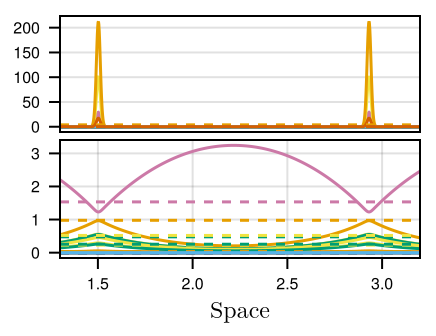

In [113]:
iK = 2
ir = 2
ps = fparams[ir,iK]
ode_fs = fode_fss[ir,iK]
pde_fs = fsp_fss[ir,iK];

rcs = f["ode_retcodes"][ir,iK], f["sp_retcodes"][ir,iK]
@show rcs

fig = Figure(;
    size=(double_col_width * 0.32, (double_col_width / golden_ratio) * 0.4),
    figure_padding=(8., 8., 8., 8.),
)

plot_spatial_fs!(fig[1,1], pde_fs, N, sN, dx, ode_fs)
sax, rax = fig.content

for ax in (sax, rax)
    ax.xlabelsize=8fontsize_ltex_pt
    ax.ylabelsize=8fontsize_ltex_pt
    ax.xticklabelsize=6fontsize_pt
    ax.yticklabelsize=6fontsize_pt
end
rax.xlabel = L"\text{Space}"

xlims!(rax, 1.3, 3.2)

Makie.save("../../figures2/fig3/sample_peak_si2.pdf", fig)

fig

rcs = (SciMLBase.ReturnCode.Success, SciMLBase.ReturnCode.Success)


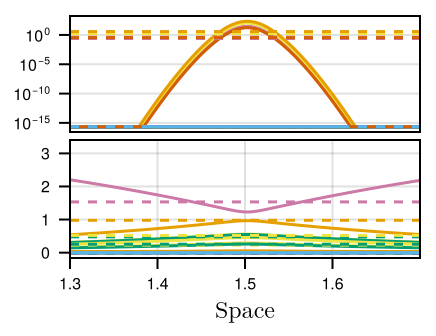

In [129]:
iK = 2
ir = 2
ps = fparams[ir,iK]
ode_fs = copy(fode_fss[ir,iK])
pde_fs = copy(fsp_fss[ir,iK])

clamp!(ode_fs, eps(), Inf)
clamp!(pde_fs, eps(), Inf)

rcs = f["ode_retcodes"][ir,iK], f["sp_retcodes"][ir,iK]
@show rcs

fig = Figure(;
    size=(double_col_width * 0.32, (double_col_width / golden_ratio) * 0.4),
    figure_padding=(8., 8., 8., 8.),
)

plot_spatial_fs!(fig[1,1], pde_fs, N, sN, dx, ode_fs)
sax, rax = fig.content

sax.yscale = log10

for ax in (sax, rax)
    ax.xlabelsize=8fontsize_ltex_pt
    ax.ylabelsize=8fontsize_ltex_pt
    ax.xticklabelsize=6fontsize_pt
    ax.yticklabelsize=6fontsize_pt
end
rax.xlabel = L"\text{Space}"

xlims!(rax, 1.3, 1.7)

Makie.save("../../figures2/fig3/sample_peak_si4.pdf", fig)

fig